# 05 · Model Evaluation & Explainability

Final, one-time evaluation on the untouched **test** split (chronologically after both
train and val — the model has never seen these transactions or their era), a
business-cost-driven decision threshold, an operational precision@review-budget view,
per-fraud-pattern recall, and SHAP explainability (global + individual-transaction).

Explainability isn't a nice-to-have here — a fraud model that flags a transaction without
a reason is operationally useless: a fraud analyst reviewing a flagged transaction, or a
compliance team asked "why was this customer declined," both need a specific answer.

In [1]:
%matplotlib inline
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import mlflow
import mlflow.xgboost
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

with open("../data/processed/feature_columns.json") as f:
    cfg = json.load(f)
FEATURES, LABEL = cfg["features"], cfg["label"]

test = pd.read_parquet("../data/processed/test.parquet").reset_index(drop=True)
X_test, y_test = test[FEATURES], test[LABEL]

mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath('../mlflow.db')}")
model = mlflow.xgboost.load_model("models:/fraud-xgboost@staging")

test_proba = model.predict_proba(X_test)[:, 1]
print(f"test set: {X_test.shape}, fraud rate={y_test.mean():.4%}")

test set: (157286, 19), fraud rate=0.6059%


## Ranking quality: ROC-AUC and PR-AUC on the hold-out test set

Test ROC-AUC: 0.9888
Test PR-AUC:  0.6816  (baseline = fraud rate = 0.0061)


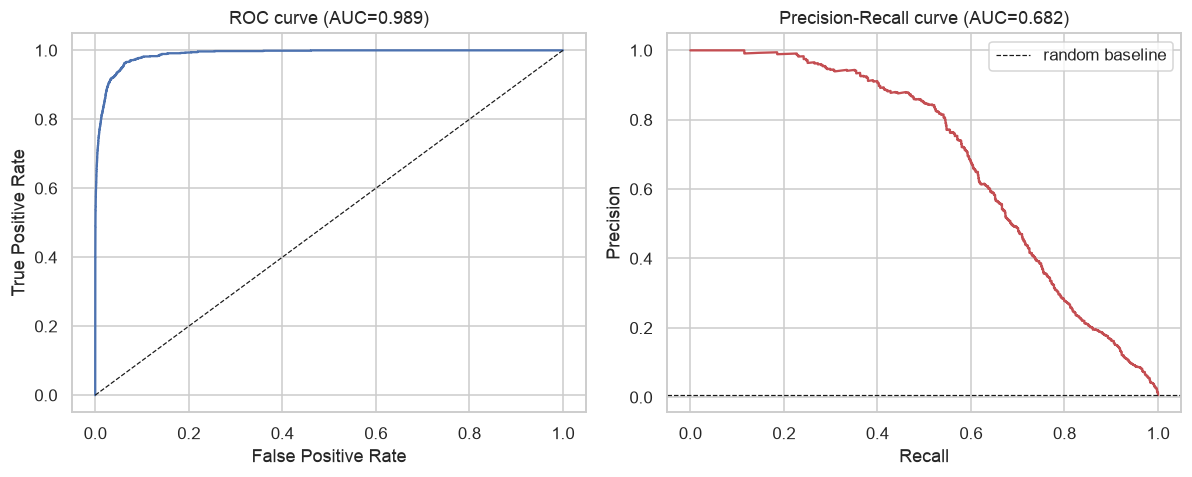

In [2]:
roc_auc = roc_auc_score(y_test, test_proba)
pr_auc = average_precision_score(y_test, test_proba)
print(f"Test ROC-AUC: {roc_auc:.4f}")
print(f"Test PR-AUC:  {pr_auc:.4f}  (baseline = fraud rate = {y_test.mean():.4f})")

fpr, tpr, _ = roc_curve(y_test, test_proba)
prec, rec, _ = precision_recall_curve(y_test, test_proba)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color="#4C72B0")
axes[0].plot([0, 1], [0, 1], "k--", linewidth=0.8)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title(f"ROC curve (AUC={roc_auc:.3f})")

axes[1].plot(rec, prec, color="#C44E52")
axes[1].axhline(y_test.mean(), color="k", linestyle="--", linewidth=0.8, label="random baseline")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title(f"Precision-Recall curve (AUC={pr_auc:.3f})")
axes[1].legend()
plt.tight_layout()
plt.show()

## Business-cost-driven decision threshold

A default 0.5 cutoff is meaningless here — it's not tied to what a false positive or false
negative actually costs the business. We model:

- **Missed fraud (false negative)**: the full transaction amount is lost (chargeback + fees)
- **False alarm (false positive)**: a fixed operational cost of manually reviewing / declining
  a legitimate transaction (customer friction, support load) — assumed **\$5** per review

Then we sweep the decision threshold and pick the one that **minimizes total expected cost**,
rather than optimizing a proxy metric like F1.

Optimal threshold: 0.02
Expected cost @ optimal threshold: $36,841
Cost of approving everything (no model): $511,283
Cost of manually reviewing everything:    $786,430
Estimated savings vs. no model: $474,442 (92.8% reduction)


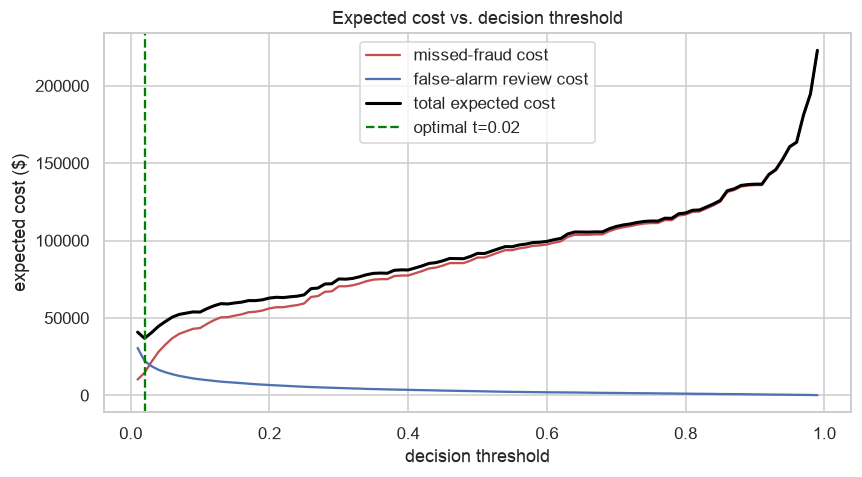

In [3]:
REVIEW_COST = 5.0
amounts = test["amount"].values
y_arr = y_test.values

thresholds = np.linspace(0.01, 0.99, 99)
total_costs, fn_costs, fp_costs = [], [], []
for t in thresholds:
    pred = (test_proba >= t).astype(int)
    fn_mask = (pred == 0) & (y_arr == 1)
    fp_mask = (pred == 1) & (y_arr == 0)
    fn_cost = amounts[fn_mask].sum()
    fp_cost = REVIEW_COST * fp_mask.sum()
    fn_costs.append(fn_cost); fp_costs.append(fp_cost); total_costs.append(fn_cost + fp_cost)

total_costs = np.array(total_costs)
best_idx = total_costs.argmin()
best_threshold = thresholds[best_idx]

no_model_cost = amounts[y_arr == 1].sum()             # approve everything
review_all_cost = REVIEW_COST * len(test)               # manually review everything

print(f"Optimal threshold: {best_threshold:.2f}")
print(f"Expected cost @ optimal threshold: ${total_costs[best_idx]:,.0f}")
print(f"Cost of approving everything (no model): ${no_model_cost:,.0f}")
print(f"Cost of manually reviewing everything:    ${review_all_cost:,.0f}")
print(f"Estimated savings vs. no model: ${no_model_cost - total_costs[best_idx]:,.0f} "
      f"({(1 - total_costs[best_idx] / no_model_cost):.1%} reduction)")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thresholds, fn_costs, label="missed-fraud cost", color="#C44E52")
ax.plot(thresholds, fp_costs, label="false-alarm review cost", color="#4C72B0")
ax.plot(thresholds, total_costs, label="total expected cost", color="black", linewidth=2)
ax.axvline(best_threshold, color="green", linestyle="--", label=f"optimal t={best_threshold:.2f}")
ax.set_xlabel("decision threshold"); ax.set_ylabel("expected cost ($)")
ax.set_title("Expected cost vs. decision threshold")
ax.legend()
plt.tight_layout()
plt.show()

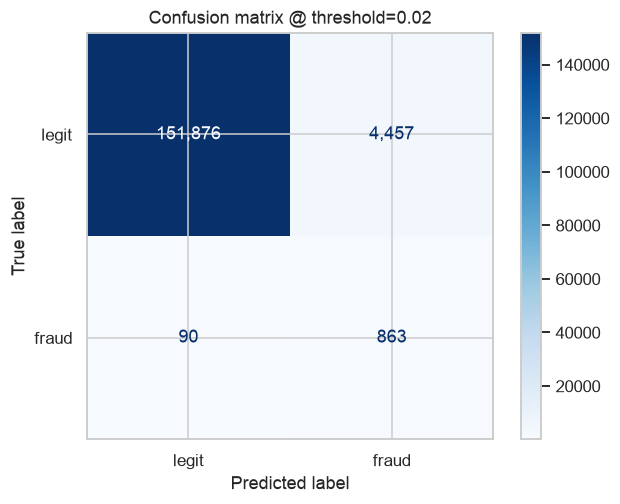

              precision    recall  f1-score   support

       legit      0.999     0.971     0.985    156333
       fraud      0.162     0.906     0.275       953

    accuracy                          0.971    157286
   macro avg      0.581     0.939     0.630    157286
weighted avg      0.994     0.971     0.981    157286



In [4]:
test_eval = test.copy()
test_eval["proba"] = test_proba
test_eval["pred"] = (test_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, test_eval["pred"])
ConfusionMatrixDisplay(cm, display_labels=["legit", "fraud"]).plot(cmap="Blues", values_format=",d")
plt.title(f"Confusion matrix @ threshold={best_threshold:.2f}")
plt.show()

print(classification_report(y_test, test_eval["pred"], target_names=["legit", "fraud"], digits=3))

## Operational view: precision at a fixed daily review budget

Fraud/risk teams operate under a fixed analyst review capacity, not a fixed threshold. This answers: *"if we can only manually review N transactions per day, how many frauds do we actually catch?"*

In [5]:
n_days_test = (test.timestamp.max() - test.timestamp.min()).days or 1
daily_budgets = [10, 25, 50, 100, 200]
order = np.argsort(-test_proba)
rows = []
for budget in daily_budgets:
    k = budget * n_days_test
    k = min(k, len(test))
    top_k = order[:k]
    caught = y_arr[top_k].sum()
    rows.append({
        "review_budget_per_day": budget,
        "total_reviewed": k,
        "fraud_caught": int(caught),
        "precision": caught / k,
        "recall_of_all_fraud": caught / y_arr.sum(),
    })
pd.DataFrame(rows)

,review_budget_per_day,total_reviewed,fraud_caught,precision,recall_of_all_fraud
0,10,770,556,0.722078,0.583421
1,25,1925,717,0.372468,0.752361
2,50,3850,809,0.210130,0.848898
3,100,7700,885,0.114935,0.928646
4,200,15400,931,0.060455,0.976915


## Recall by merchant category and by distance-from-home

Without injected "pattern" labels (this is real data — we don't get to know the fraud taxonomy in advance), we instead check whether recall is uniform across the two strongest signals surfaced in the EDA: merchant category and distance from the cardholder's home.

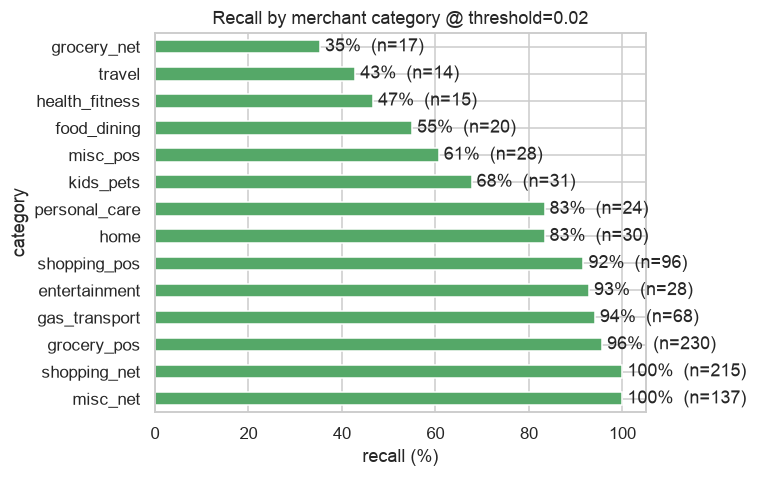

In [6]:
by_cat = test_eval[test_eval.is_fraud == 1].groupby("category").agg(
    n=("pred", "size"), caught=("pred", "sum")
)
by_cat["recall"] = by_cat.caught / by_cat.n
by_cat = by_cat[by_cat.n >= 5].sort_values("recall", ascending=False)

ax = (by_cat["recall"] * 100).plot(kind="barh", figsize=(7, 4.5), color="#55A868")
ax.set_xlabel("recall (%)")
ax.set_title(f"Recall by merchant category @ threshold={best_threshold:.2f}")
for i, (v, n) in enumerate(zip(by_cat["recall"].values, by_cat["n"].values)):
    ax.text(v * 100, i, f" {v:.0%}  (n={n})", va="center")
plt.tight_layout()
plt.show()

In [7]:
dist_bins = pd.cut(test_eval["distance_from_home_km"], bins=[0, 20, 50, 100, 250, 100000],
                    labels=["0-20km", "20-50km", "50-100km", "100-250km", "250km+"])
by_dist = test_eval[test_eval.is_fraud == 1].groupby(dist_bins, observed=True).agg(
    n=("pred", "size"), caught=("pred", "sum")
)
by_dist["recall"] = by_dist.caught / by_dist.n
by_dist

,n,caught,recall
distance_from_home_km,,,
0-20km,29,28,0.965517
20-50km,177,154,0.870056
50-100km,544,498,0.915441
100-250km,203,183,0.901478


## SHAP: global feature importance

Using `TreeExplainer` for exact, fast Shapley values on the gradient-boosted model (sampled for plotting speed).

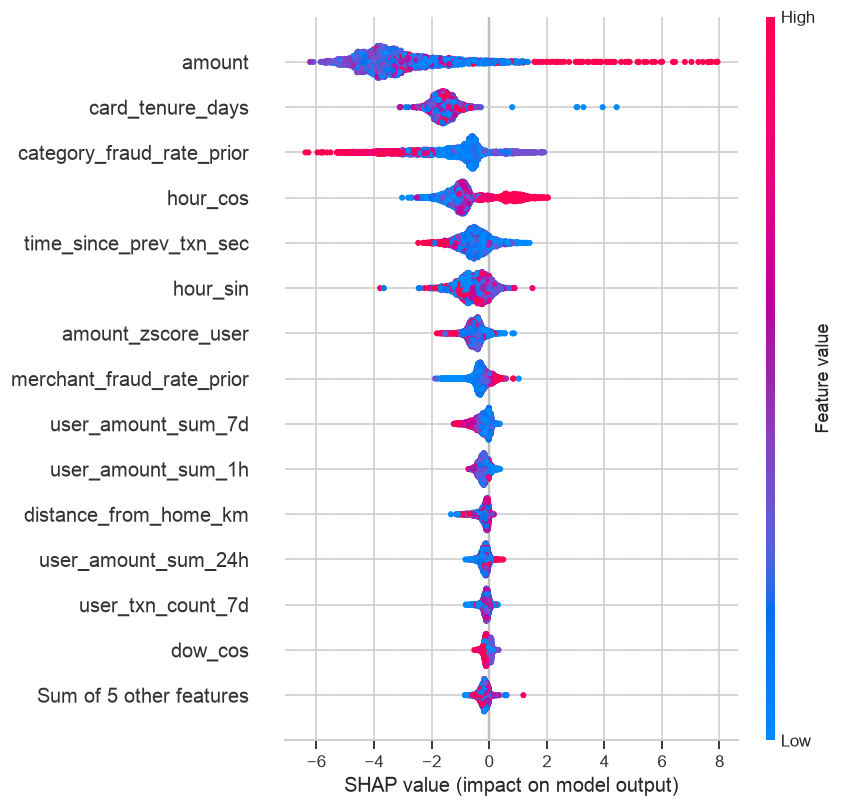

In [8]:
explainer = shap.TreeExplainer(model)

rng = np.random.default_rng(42)
sample_idx = rng.choice(len(X_test), size=min(3000, len(X_test)), replace=False)
X_sample = X_test.iloc[sample_idx]
shap_values = explainer(X_sample)

shap.plots.beeswarm(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.show()

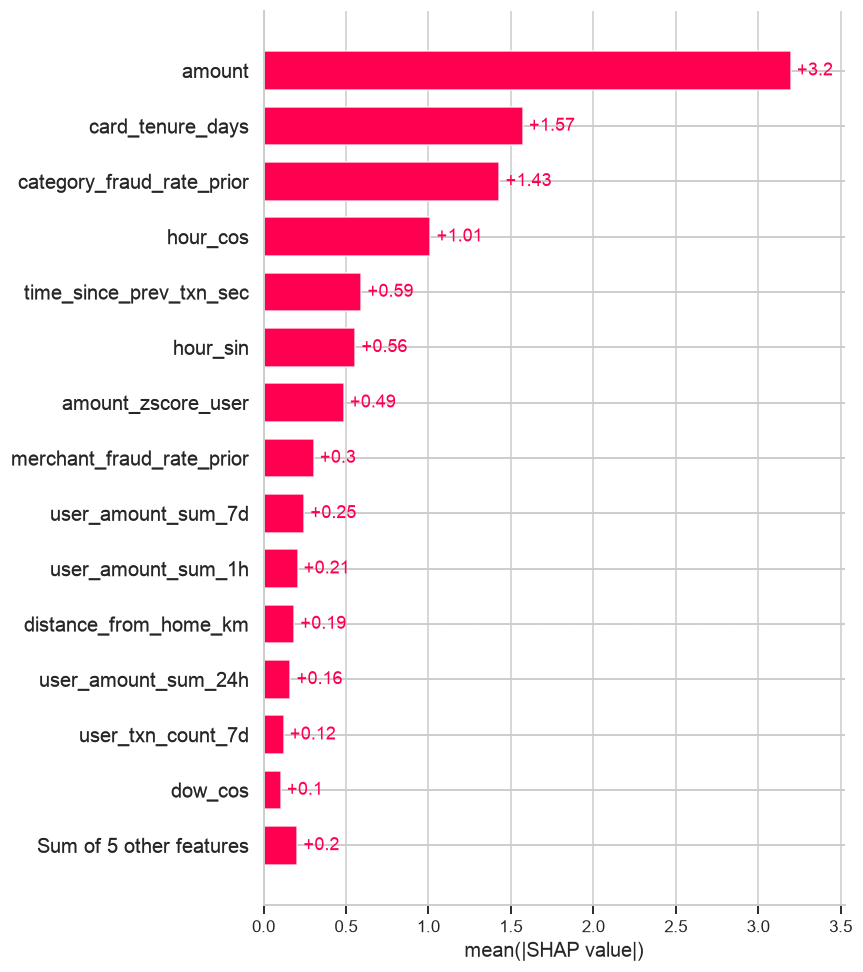

In [9]:
shap.plots.bar(shap_values, show=False, max_display=15)
plt.tight_layout()
plt.show()

## SHAP: individual transaction explanations

One confident **true positive** (correctly caught fraud) and one **false negative** (a fraud transaction the model missed) — the kind of side-by-side an analyst or model-risk reviewer would actually ask for.

True positive example: category=misc_net, amount=$805.42, score=1.000


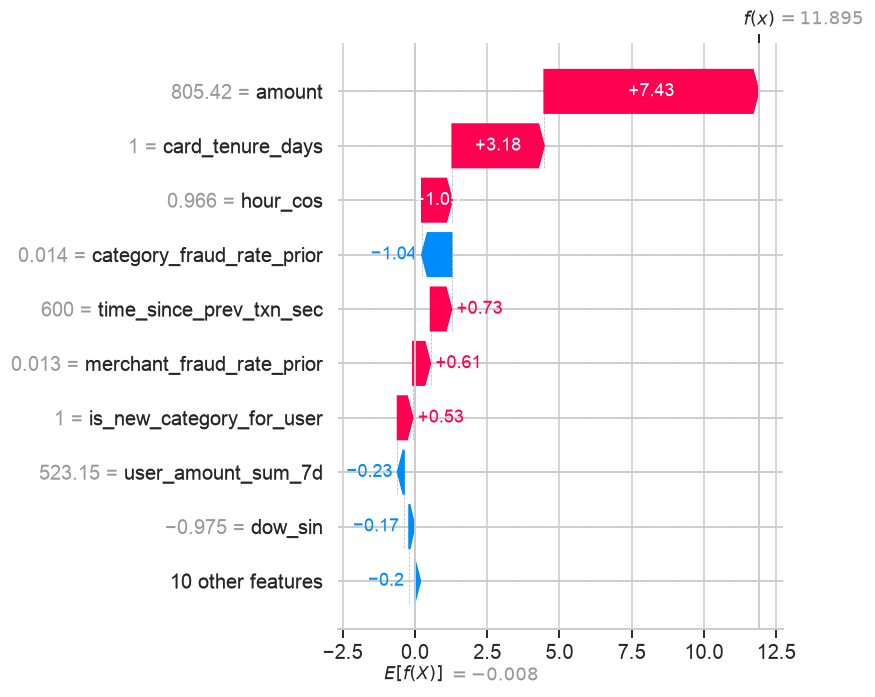

False negative example: category=health_fitness, amount=$18.16, score=0.001


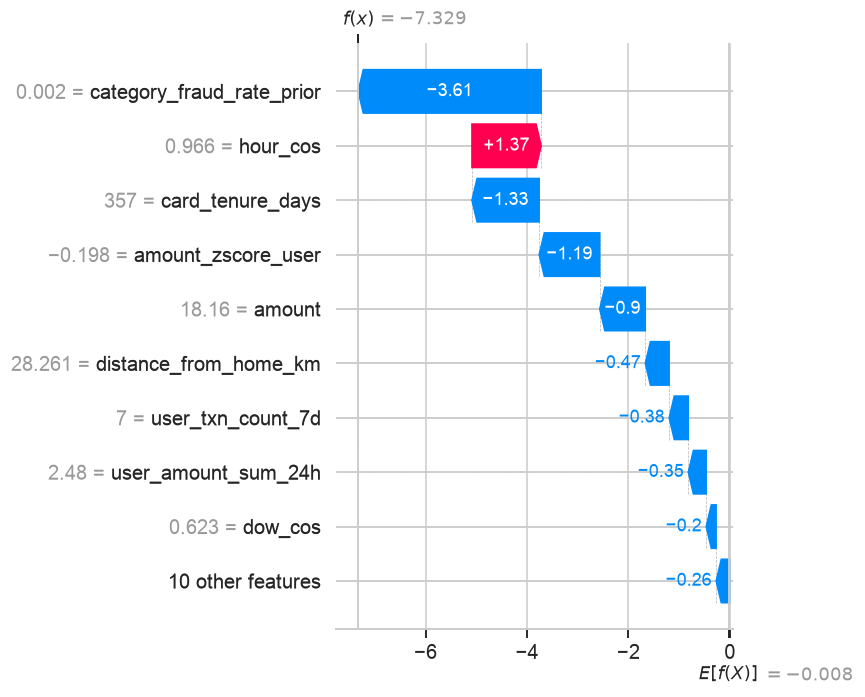

In [10]:
tp_candidates = test_eval[(test_eval.is_fraud == 1) & (test_eval.pred == 1)].sort_values("proba", ascending=False)
fn_candidates = test_eval[(test_eval.is_fraud == 1) & (test_eval.pred == 0)]

tp_idx = tp_candidates.index[0]
print(f"True positive example: category={test_eval.loc[tp_idx, 'category']}, "
      f"amount=${test_eval.loc[tp_idx, 'amount']:.2f}, score={test_eval.loc[tp_idx, 'proba']:.3f}")
exp_tp = explainer(X_test.iloc[[tp_idx]])
shap.plots.waterfall(exp_tp[0], show=False)
plt.tight_layout()
plt.show()

if len(fn_candidates) > 0:
    fn_idx = fn_candidates.index[0]
    print(f"False negative example: category={test_eval.loc[fn_idx, 'category']}, "
          f"amount=${test_eval.loc[fn_idx, 'amount']:.2f}, score={test_eval.loc[fn_idx, 'proba']:.3f}")
    exp_fn = explainer(X_test.iloc[[fn_idx]])
    shap.plots.waterfall(exp_fn[0], show=False)
    plt.tight_layout()
    plt.show()
else:
    print("No false negatives at this threshold.")

## Save evaluation artifacts

The chosen threshold and headline metrics are persisted so the real-time scoring service (`src/api/`, next phase) uses the *same* threshold this notebook validated — not a re-guessed default.

In [11]:
os.makedirs("../reports", exist_ok=True)
os.makedirs("../models", exist_ok=True)

summary = {
    "test_roc_auc": float(roc_auc),
    "test_pr_auc": float(pr_auc),
    "decision_threshold": float(best_threshold),
    "review_cost_per_fp": REVIEW_COST,
    "estimated_savings_vs_no_model": float(no_model_cost - total_costs[best_idx]),
    "recall_by_category": by_cat["recall"].round(4).to_dict(),
    "n_test_transactions": int(len(test)),
    "test_fraud_rate": float(y_test.mean()),
}
with open("../reports/evaluation_summary.json", "w") as f:
    json.dump(summary, f, indent=2)
with open("../models/threshold.json", "w") as f:
    json.dump({"decision_threshold": float(best_threshold)}, f, indent=2)

print(json.dumps(summary, indent=2))

{
  "test_roc_auc": 0.9888486887391861,
  "test_pr_auc": 0.6816269514961734,
  "decision_threshold": 0.02,
  "review_cost_per_fp": 5.0,
  "estimated_savings_vs_no_model": 474441.74,
  "recall_by_category": {
    "misc_net": 1.0,
    "shopping_net": 1.0,
    "grocery_pos": 0.9565,
    "gas_transport": 0.9412,
    "entertainment": 0.9286,
    "shopping_pos": 0.9167,
    "home": 0.8333,
    "personal_care": 0.8333,
    "kids_pets": 0.6774,
    "misc_pos": 0.6071,
    "food_dining": 0.55,
    "health_fitness": 0.4667,
    "travel": 0.4286,
    "grocery_net": 0.3529
  },
  "n_test_transactions": 157286,
  "test_fraud_rate": 0.006059026232468243
}
